# Multivariate Multi-Horizon Time Series Forecasting (Bitcoin)

# 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Reproducibility Configuration

In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3. Load Dataset

In [3]:
df = pd.read_csv('/content/Bitcoin3.csv')

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna()

df = df.sort_values('Date').set_index('Date')

df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


# 4. Feature Correlation Heatmap

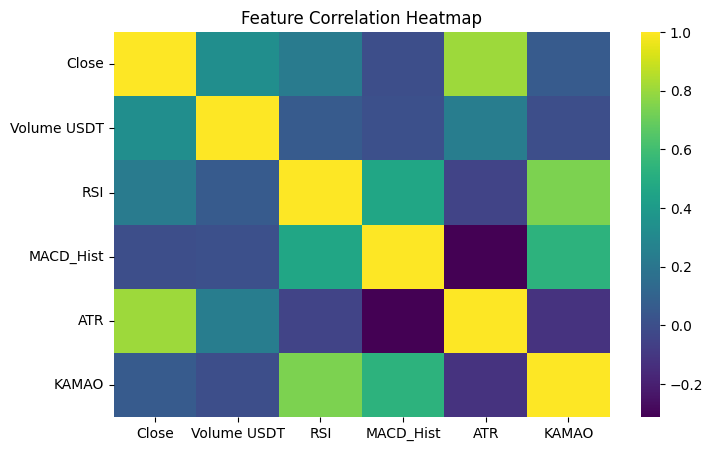

In [4]:
features_base = [
    'Close',
    'Volume USDT',
    'RSI',
    'MACD_Hist',
    'ATR',
    'KAMAO']

plt.figure(figsize=(8,5))

sns.heatmap(
    df[features_base].corr(),
    cmap='viridis')

plt.title('Feature Correlation Heatmap')
plt.show()

# 5. Seasonal Decomposition

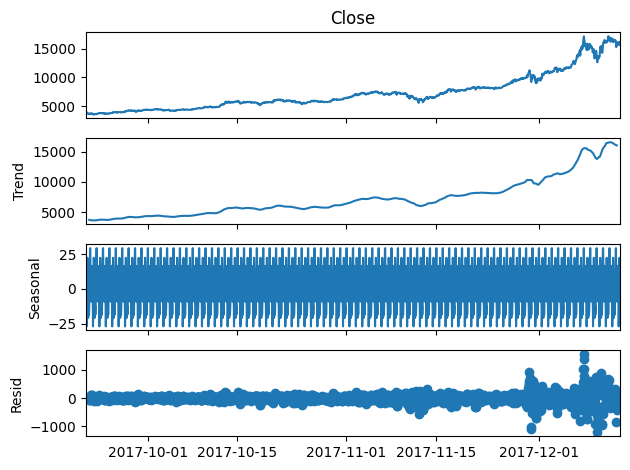

In [5]:
decomp = seasonal_decompose(
    df['Close'][:2000],
    model='additive',
    period=24)

decomp.plot()
plt.show()

# 6. ACF and PACF Analysis

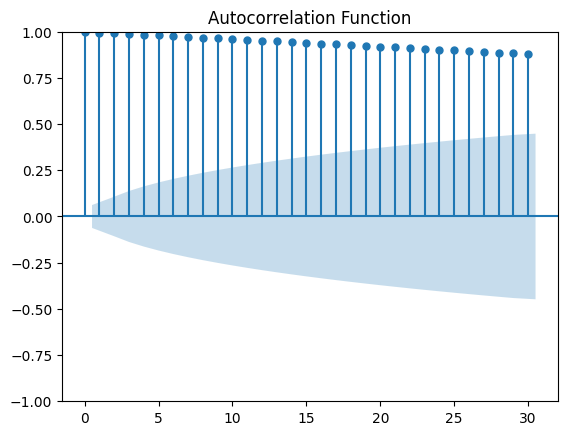

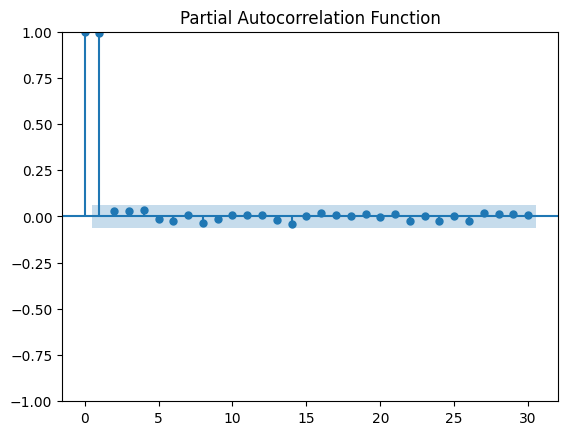

Significant lag appears around 48 steps, therefore WINDOW=48 is selected.


In [6]:
plot_acf(df['Close'][:1000])
plt.title('Autocorrelation Function')
plt.show()

plot_pacf(df['Close'][:1000])
plt.title('Partial Autocorrelation Function')
plt.show()

print(
    'Significant lag appears around 48 steps, '
    'therefore WINDOW=48 is selected.'
)

# 7. Window Size Justification

In [7]:
WINDOW = 48
HORIZON = 24

print('Window Size:', WINDOW)
print('Forecast Horizon:', HORIZON)

Window Size: 48
Forecast Horizon: 24


# 8. Feature Engineering

In [8]:
df['roll_mean_24'] = df['Close'].rolling(24).mean()
df['roll_std_24'] = df['Close'].rolling(24).std()
df['return_1'] = df['Close'].pct_change()

df = df.dropna()

# 9. Train Validation Test Split

In [9]:
features = [
    'Close',
    'Volume USDT',
    'RSI',
    'MACD_Hist',
    'ATR',
    'KAMAO',
    'roll_mean_24',
    'roll_std_24',
    'return_1'
]

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

print('Train Size:', len(train_df))
print('Validation Size:', len(val_df))
print('Test Size:', len(test_df))

print(
    f'Train Ratio: {len(train_df)/len(df):.2f}'
)

print(
    f'Validation Ratio: {len(val_df)/len(df):.2f}'
)

print(
    f'Test Ratio: {len(test_df)/len(df):.2f}'
)

Train Size: 11650
Validation Size: 2496
Test Size: 2497
Train Ratio: 0.70
Validation Ratio: 0.15
Test Ratio: 0.15


# 10. Feature Scaling

In [10]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features])

val_scaled = scaler.transform(val_df[features])
test_scaled = scaler.transform(test_df[features])

# 11. Dataset Windowing with Teacher Forcing

In [11]:
def create_dataset(data):

    encoder_input = []
    decoder_input = []
    decoder_target = []

    for i in range(len(data) - WINDOW - HORIZON):

        x_enc = data[i:i+WINDOW]

        y_seq = data[i+WINDOW:i+WINDOW+HORIZON, 0]

        dec_in = np.concatenate(([0], y_seq[:-1]))

        encoder_input.append(x_enc)

        decoder_input.append(dec_in.reshape(-1,1))

        decoder_target.append(y_seq)

    return (
    np.array(
        encoder_input,
        dtype=np.float32),

    np.array(
        decoder_input,
        dtype=np.float32),

    np.array(
        decoder_target,
        dtype=np.float32))

X_train_enc, X_train_dec, y_train = create_dataset(train_scaled)
X_val_enc, X_val_dec, y_val = create_dataset(val_scaled)
X_test_enc, X_test_dec, y_test = create_dataset(test_scaled)

print('Train Encoder Shape:', X_train_enc.shape)
print('Validation Encoder Shape:', X_val_enc.shape)
print('Test Encoder Shape:', X_test_enc.shape)

Train Encoder Shape: (11578, 48, 9)
Validation Encoder Shape: (2424, 48, 9)
Test Encoder Shape: (2425, 48, 9)


# 12. TensorFlow Dataset Pipeline

In [12]:
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_train_enc, X_train_dec), y_train)
).shuffle(
    2000
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_val_enc, X_val_dec), y_val)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_test_enc, X_test_dec), y_test)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

# 13. Custom Dense Layer

In [13]:
class CustomDense(tf.keras.layers.Layer):

    def __init__(self, units):

        super().__init__()

        self.units = units

    def build(self, input_shape):

        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform')

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros')

    def call(self, x):

        return tf.matmul(x, self.w) + self.b

# 14. Custom Layer Normalization

In [14]:
class CustomLayerNorm(tf.keras.layers.Layer):

    def __init__(self, epsilon=1e-6):

        super().__init__()

        self.epsilon = epsilon

    def build(self, input_shape):

        self.gamma = self.add_weight(
            shape=input_shape[-1:],
            initializer='ones')

        self.beta = self.add_weight(
            shape=input_shape[-1:],
            initializer='zeros')

    def call(self, x):

        mean = tf.reduce_mean(x, axis=-1, keepdims=True)

        variance = tf.reduce_mean(
            tf.square(x - mean),
            axis=-1,
            keepdims=True)

        normalized = (x - mean) / tf.sqrt(
            variance + self.epsilon)

        return self.gamma * normalized + self.beta

# 15. Custom Dropout Layer

In [15]:
class CustomDropout(tf.keras.layers.Layer):

    def __init__(self, rate):

        super().__init__()

        self.rate = rate

    def call(self, x, training=False):

        if training:

            mask = tf.cast(
                tf.random.uniform(tf.shape(x)) > self.rate,
                tf.float32)

            return x * mask / (1.0 - self.rate)

        return x

# 16. Custom Multi Head Attention

In [16]:
class CustomMultiHeadAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.num_heads = num_heads

        self.d_model = d_model

        self.depth = d_model // num_heads

        self.wq = CustomDense(d_model)

        self.wk = CustomDense(d_model)

        self.wv = CustomDense(d_model)

        self.dense = CustomDense(d_model)

    def split_heads(self, x, batch_size):

        x = tf.reshape(
            x,
            (batch_size, -1, self.num_heads, self.depth))

        return tf.transpose(x, perm=[0,2,1,3])

    def scaled_dot_product_attention(self, q, k, v):

        matmul_qk = tf.matmul(q, k, transpose_b=True)

        dk = tf.cast(tf.shape(k)[-1], tf.float32)

        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(
            scaled_attention_logits,
            axis=-1)

        output = tf.matmul(attention_weights, v)
        return output

    def call(self, q, k, v):

        batch_size = tf.shape(q)[0]

        q = self.wq(q)

        k = self.wk(k)

        v = self.wv(v)

        q = self.split_heads(q, batch_size)

        k = self.split_heads(k, batch_size)

        v = self.split_heads(v, batch_size)

        scaled_attention = self.scaled_dot_product_attention(
            q, k, v)

        scaled_attention = tf.transpose(
            scaled_attention,
            perm=[0,2,1,3])

        concat_attention = tf.reshape(
            scaled_attention,
            (batch_size, -1, self.d_model))

        return self.dense(concat_attention)

# 17. Baseline LSTM Architecture

In [17]:
baseline_input = tf.keras.Input(
    shape=(WINDOW, len(features))
)

x = tf.keras.layers.LSTM(
    64,
    return_sequences=True
)(baseline_input)

attention_layer = CustomMultiHeadAttention(
    d_model=64,
    num_heads=4
)

x = attention_layer(x, x, x)

x = CustomLayerNorm()(x)

x = CustomDropout(0.2)(x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = CustomDense(64)(x)

x = tf.keras.layers.ReLU()(x)

baseline_output = tf.keras.layers.Dense(
    HORIZON
)(x)

baseline_model = tf.keras.Model(
    baseline_input,
    baseline_output
)

dummy_baseline = tf.random.normal(
    (1, WINDOW, len(features))
)

_ = baseline_model(
    dummy_baseline,
    training=False
)

baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 48, 64)    │     18,944 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 64)  │     16,640 │ lstm[0][0],       │
│ (CustomMultiHeadAt… │                   │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_layer_norm   │ (None, None, 64)  │        128 │ custom_multi_hea… │
│ (CustomLayerNorm)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout      │ (None, None, 64)  │          0 │ custom_layer_nor… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ custom_dropout[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dense_4      │ (None, 64)        │      4,160 │ global_average_p… │
│ (CustomDense)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64)        │          0 │ custom_dense_4[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24)        │      1,560 │ re_lu[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,432 (161.84 KB)

 Trainable params: 41,432 (161.84 KB)

 Non-trainable params: 0 (0.00 B)

# 18. Seq2Seq Teacher Forcing Architecture

In [18]:
class Seq2Seq(tf.keras.Model):

    def __init__(self):

        super().__init__()

        self.encoder = tf.keras.layers.LSTM(
            64,
            return_sequences=True,
            return_state=True
        )

        self.decoder = tf.keras.layers.LSTM(
            64,
            return_sequences=True,
            return_state=True
        )

        self.attention = CustomMultiHeadAttention(
            d_model=64,
            num_heads=4
        )

        self.norm = CustomLayerNorm()

        self.dropout = CustomDropout(0.2)

        self.final_dense = CustomDense(64)

        self.relu = tf.keras.layers.ReLU()

        self.output_layer = CustomDense(1)

    def call(self, inputs, training=False):

        enc_input, dec_input = inputs

        enc_out, h, c = self.encoder(
            enc_input
        )

        dec_out, _, _ = self.decoder(
            dec_input,
            initial_state=[h, c]
        )

        attn = self.attention(
            dec_out,
            enc_out,
            enc_out
        )

        x = self.norm(
            attn + dec_out
        )

        x = self.dropout(
            x,
            training=training
        )

        x = self.final_dense(x)

        x = self.relu(x)

        out = self.output_layer(x)

        return tf.squeeze(
            out,
            axis=-1
        )

seq2seq_model = Seq2Seq()

dummy_enc = tf.random.normal(
    (1, WINDOW, len(features))
)

dummy_dec = tf.random.normal(
    (1, HORIZON, 1)
)

_ = seq2seq_model(
    (dummy_enc, dummy_dec),
    training=False
)

seq2seq_model.summary()

Model: "seq2_seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ ((1, 48, 64), (1, 64), │        18,944 │
│                                 │ (1, 64))               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ((1, 24, 64), (1, 64), │        16,896 │
│                                 │ (1, 64))               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_multi_head_attention_1   │ ?                      │        16,640 │
│ (CustomMultiHeadAttention)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_layer_norm_1             │ ?                      │           128 │
│ (CustomLayerNorm)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout_1                │ ?                      │             0 │
│ (CustomDropout)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_9 (CustomDense)    │ ?                      │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_10 (CustomDense)   │ ?                      │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,833 (222.00 KB)

 Trainable params: 56,833 (222.00 KB)

 Non-trainable params: 0 (0.00 B)

# 19. Custom Weighted Horizon Loss

In [19]:
def weighted_horizon_mae(y_true, y_pred):

    y_true = tf.cast(
        y_true,
        tf.float32)

    y_pred = tf.cast(
        y_pred,
        tf.float32)

    weights = tf.linspace(
        1.0,
        2.5,
        HORIZON)

    error = tf.abs(
        y_true - y_pred)

    weighted_error = error * weights

    return tf.reduce_mean(
        weighted_error)

# 20. Custom Callbacks

In [20]:
class CustomEarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.best_loss = np.inf

        self.wait = 0

        self.stop_training = False

    def __call__(self, current_loss):

        if current_loss < self.best_loss:

            self.best_loss = current_loss

            self.wait = 0

        else:

            self.wait += 1

            if self.wait >= self.patience:

                self.stop_training = True

class CustomReduceLR:

    def __init__(
        self,
        optimizer,
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ):

        self.optimizer = optimizer

        self.factor = factor

        self.patience = patience

        self.min_lr = min_lr

        self.best_loss = np.inf

        self.wait = 0

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.wait = 0

        else:

            self.wait += 1

            if self.wait >= self.patience:

                current_lr = float(
                    self.optimizer.learning_rate.numpy())

                new_lr = max(
                    current_lr * self.factor,
                    self.min_lr)

                self.optimizer.learning_rate.assign(new_lr)

                print(
                    f'Learning Rate Reduced: {new_lr}')

                self.wait = 0

# 21. Optimizer Configuration

In [21]:
baseline_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

seq2seq_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

baseline_model.compile(
    optimizer=baseline_optimizer,
    loss=weighted_horizon_mae
)

seq2seq_model.compile(
    optimizer=seq2seq_optimizer,
    loss=weighted_horizon_mae
)

# 22. Custom Training Steps

In [22]:
@tf.function
def baseline_train_step(inputs, target):

    with tf.GradientTape() as tape:

        prediction = baseline_model(
            inputs,
            training=True)

        loss = weighted_horizon_mae(
            target,
            prediction)

    gradients = tape.gradient(
        loss,
        baseline_model.trainable_variables)

    baseline_optimizer.apply_gradients(
        zip(
            gradients,
            baseline_model.trainable_variables))

    return loss


@tf.function
def seq2seq_train_step(inputs, target):

    with tf.GradientTape() as tape:

        prediction = seq2seq_model(
            inputs,
            training=True)

        loss = weighted_horizon_mae(
            target,
            prediction)

    gradients = tape.gradient(
        loss,
        seq2seq_model.trainable_variables)

    seq2seq_optimizer.apply_gradients(
        zip(
            gradients,
            seq2seq_model.trainable_variables))

    return loss


@tf.function
def seq2seq_validation_step(inputs, target):

    prediction = seq2seq_model(
        inputs,
        training=False)

    loss = weighted_horizon_mae(
        target,
        prediction)

    return loss

# 23. Baseline Custom Training Loop

In [23]:
BASELINE_EPOCHS = 20

for epoch in range(BASELINE_EPOCHS):

    train_losses = []

    for batch_x, batch_y in train_ds:

        encoder_input = batch_x[0]

        loss = baseline_train_step(
            encoder_input,
            batch_y
        )

        train_losses.append(
            loss.numpy()
        )

    print(
        f'Baseline Epoch {epoch+1} | '
        f'Loss: {np.mean(train_losses):.5f}'
    )

Baseline Epoch 1 | Loss: 0.10811
Baseline Epoch 2 | Loss: 0.05453
Baseline Epoch 3 | Loss: 0.04497
Baseline Epoch 4 | Loss: 0.03861
Baseline Epoch 5 | Loss: 0.03355
Baseline Epoch 6 | Loss: 0.03168
Baseline Epoch 7 | Loss: 0.03029
Baseline Epoch 8 | Loss: 0.02815
Baseline Epoch 9 | Loss: 0.02803
Baseline Epoch 10 | Loss: 0.02674
Baseline Epoch 11 | Loss: 0.02607
Baseline Epoch 12 | Loss: 0.02527
Baseline Epoch 13 | Loss: 0.02717
Baseline Epoch 14 | Loss: 0.02524
Baseline Epoch 15 | Loss: 0.02595
Baseline Epoch 16 | Loss: 0.02412
Baseline Epoch 17 | Loss: 0.02378
Baseline Epoch 18 | Loss: 0.02552
Baseline Epoch 19 | Loss: 0.02413
Baseline Epoch 20 | Loss: 0.02411


# 24. Seq2Seq Custom Training Loop

In [24]:
EPOCHS = 20

early_stop = CustomEarlyStopping(
    patience=5
)

reduce_lr = CustomReduceLR(
    optimizer=seq2seq_optimizer
)

best_val_loss = np.inf

for epoch in range(EPOCHS):

    train_losses = []

    for batch_inputs, batch_target in train_ds:

        loss = seq2seq_train_step(
            batch_inputs,
            batch_target
        )

        train_losses.append(
            loss.numpy()
        )

    val_losses = []

    for val_inputs, val_target in val_ds:

        val_loss = seq2seq_validation_step(
            val_inputs,
            val_target
        )

        val_losses.append(
            val_loss.numpy()
        )

    train_mean = np.mean(
        train_losses
    )

    val_mean = np.mean(
        val_losses
    )

    print(
        f'Epoch {epoch+1}/{EPOCHS} | '
        f'Loss: {train_mean:.5f} | '
        f'Val Loss: {val_mean:.5f}'
    )

    if val_mean < best_val_loss:

        best_val_loss = val_mean

        seq2seq_model.save(
            'best_model_seq2seq_LSTM.keras'
        )

    reduce_lr(val_mean)

    early_stop(val_mean)

    if early_stop.stop_training:

        print(
            'Early Stopping Triggered'
        )

        break

Epoch 1/20 | Loss: 0.11756 | Val Loss: 0.00784
Epoch 2/20 | Loss: 0.03813 | Val Loss: 0.00924
Epoch 3/20 | Loss: 0.03564 | Val Loss: 0.00611
Epoch 4/20 | Loss: 0.03052 | Val Loss: 0.00504
Epoch 5/20 | Loss: 0.02829 | Val Loss: 0.01952
Epoch 6/20 | Loss: 0.02456 | Val Loss: 0.00485
Epoch 7/20 | Loss: 0.02887 | Val Loss: 0.00821
Epoch 8/20 | Loss: 0.02240 | Val Loss: 0.00798
Epoch 9/20 | Loss: 0.02319 | Val Loss: 0.00694
Learning Rate Reduced: 0.0005000000237487257
Epoch 10/20 | Loss: 0.01925 | Val Loss: 0.00244
Epoch 11/20 | Loss: 0.01906 | Val Loss: 0.00458
Epoch 12/20 | Loss: 0.01941 | Val Loss: 0.00243
Epoch 13/20 | Loss: 0.01868 | Val Loss: 0.00407
Epoch 14/20 | Loss: 0.01842 | Val Loss: 0.00476
Epoch 15/20 | Loss: 0.01832 | Val Loss: 0.01038
Learning Rate Reduced: 0.0002500000118743628
Epoch 16/20 | Loss: 0.01751 | Val Loss: 0.00551
Epoch 17/20 | Loss: 0.01710 | Val Loss: 0.00612
Early Stopping Triggered


# 25. Model Prediction

In [25]:
baseline_pred = baseline_model.predict(
    X_test_enc)

seq2seq_pred = seq2seq_model.predict(
    (X_test_enc, X_test_dec))

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


# 26. MAE Evaluation Before Inverse Scaling

In [26]:
scaled_mae = weighted_horizon_mae(
    y_test,
    seq2seq_pred
).numpy()

print('Scaled MAE:', scaled_mae)

if scaled_mae < 0.05:

    print(
        'Forecasting performance is good.'
    )

elif scaled_mae < 0.10:

    print(
        'Forecasting performance is acceptable.'
    )

else:

    print(
        'Further tuning may be required.'
    )

Scaled MAE: 0.017085003
Forecasting performance is good.


# 27. Inverse Scaling

In [27]:
def inverse_close(data, scaler):

    original_shape = data.shape

    data_flat = data.reshape(-1, 1)

    dummy = np.zeros(
        (len(data_flat), scaler.n_features_in_)
    )

    dummy[:, 0] = data_flat[:, 0]

    inversed = scaler.inverse_transform(dummy)[:, 0]

    return inversed.reshape(original_shape)

y_true = inverse_close(
    y_test,
    scaler
)

baseline_out = inverse_close(
    baseline_pred,
    scaler
)

seq2seq_out = inverse_close(
    seq2seq_pred,
    scaler
)

### Recursive forecasting is used to simulate real-world multi-step prediction where previous predictions are reused as future inputs.

# 28. Recursive Autoregressive Forecasting

In [28]:
def autoregressive_forecast(
    model,
    encoder_input,
    steps=24
):

    preds = []

    decoder_input = np.zeros(
        (1, HORIZON, 1))

    for i in range(steps):

        pred = model.predict(
            (encoder_input, decoder_input),
            verbose=0
        )[0]

        preds.append(pred[i])

        if i + 1 < HORIZON:

            decoder_input[0, i+1, 0] = pred[i]

    return np.array(preds)

sample_encoder = X_test_enc[:1]

auto_pred = autoregressive_forecast(
    seq2seq_model,
    sample_encoder)

# 29. Forecast Visualization

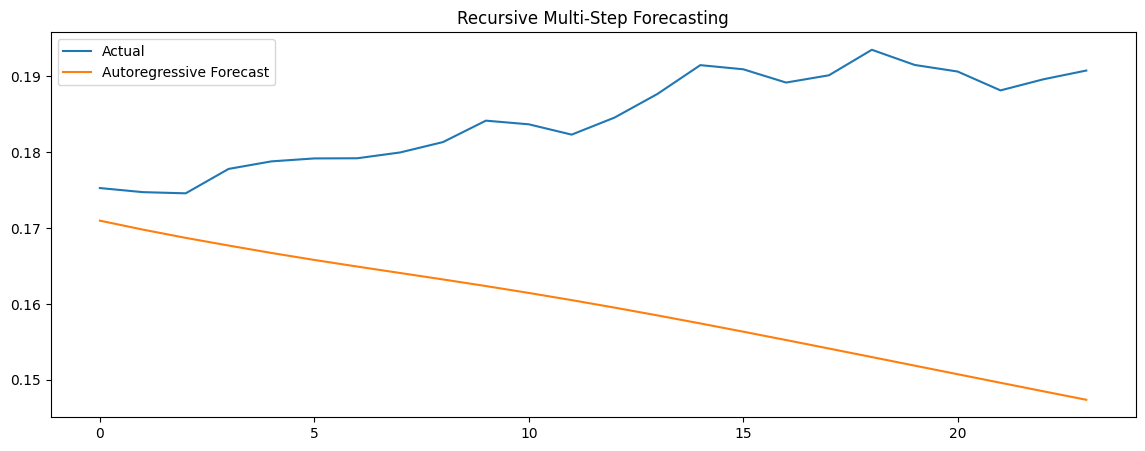

In [29]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test[0],
    label='Actual')

plt.plot(
    auto_pred,
    label='Autoregressive Forecast')

plt.title('Recursive Multi-Step Forecasting')
plt.legend()
plt.show()

# 30. MAE Comparison

In [30]:
baseline_mae = mean_absolute_error(
    y_true.flatten(),
    baseline_out.flatten()
)

seq2seq_mae = mean_absolute_error(
    y_true.flatten(),
    seq2seq_out.flatten()
)

print('MAE After Inverse Scaling')
print('Baseline MAE:', baseline_mae)
print('Seq2Seq MAE:', seq2seq_mae)

improvement = (
    (baseline_mae - seq2seq_mae)
    / baseline_mae
) * 100

print(
    f'Improvement: {improvement:.2f}%'
)

if seq2seq_mae < baseline_mae:

    print(
        'Seq2Seq model outperformed baseline model.'
    )

else:

    print(
        'Baseline model performed better.'
    )

MAE After Inverse Scaling
Baseline MAE: 327.6810735158682
Seq2Seq MAE: 162.66515108448812
Improvement: 50.36%
Seq2Seq model outperformed baseline model.


In [31]:
#RMSE Evaluation
baseline_rmse = np.sqrt(
    np.mean(
        (y_true.flatten() - baseline_out.flatten())**2
    )
)

seq2seq_rmse = np.sqrt(
    np.mean(
        (y_true.flatten() - seq2seq_out.flatten())**2
    )
)

print('RMSE Evaluation')
print('Baseline RMSE:', baseline_rmse)
print('Seq2Seq RMSE:', seq2seq_rmse)

RMSE Evaluation
Baseline RMSE: 469.3958422941902
Seq2Seq RMSE: 211.40108554177593


# 31. Prediction Comparison Table

In [32]:
comparison_df = pd.DataFrame({

    'Step': np.arange(1, HORIZON+1),

    'Actual': y_true[0],

    'Baseline': baseline_out[0],

    'Seq2Seq': seq2seq_out[0]

})

comparison_df['Baseline_Error'] = abs(
    comparison_df['Actual'] -
    comparison_df['Baseline']
)

comparison_df['Seq2Seq_Error'] = abs(
    comparison_df['Actual'] -
    comparison_df['Seq2Seq']
)

comparison_df

,Step,Actual,Baseline,Seq2Seq,Baseline_Error,Seq2Seq_Error
0,1,6070.390056,6114.060160,5999.408423,43.670105,70.981632
1,2,6061.510051,6105.549304,5996.812559,44.039253,64.697492
2,3,6058.909998,6086.035226,5998.260072,27.125229,60.649925
3,4,6112.050054,6099.618294,6002.220158,12.431760,109.829896
4,5,6128.489952,6034.708628,6019.091550,93.781324,109.398402
5,6,6134.889913,6039.882614,6040.362654,95.007299,94.527259
6,7,6135.249943,6077.076365,6061.037897,58.173578,74.212047
7,8,6147.900038,6121.513351,6077.595834,26.386686,70.304204
8,9,6170.500123,6063.893742,6091.884669,106.606382,78.615454
9,10,6217.130065,6070.748114,6106.483509,146.381951,110.646556


# 32. Horizon Degradation Analysis

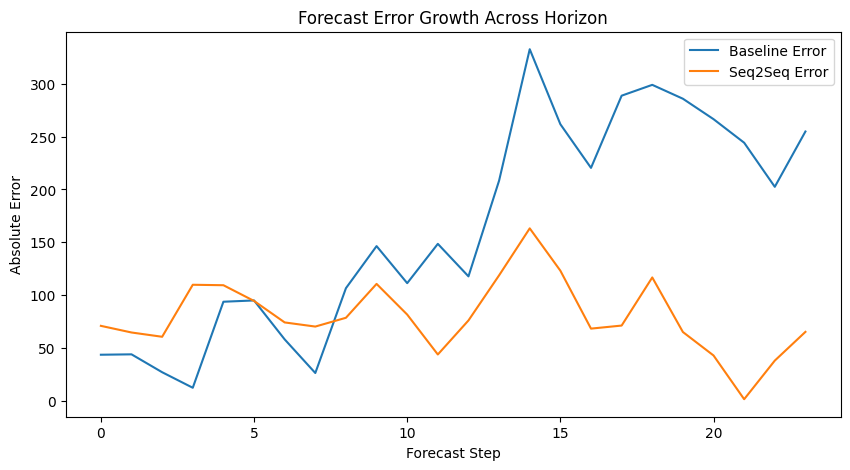

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    np.abs(y_true[0] - baseline_out[0]),
    label='Baseline Error'
)

plt.plot(
    np.abs(y_true[0] - seq2seq_out[0]),
    label='Seq2Seq Error'
)

plt.title('Forecast Error Growth Across Horizon')

plt.xlabel('Forecast Step')

plt.ylabel('Absolute Error')

plt.legend()

plt.show()

# 33. Save Final Models

In [34]:
baseline_model.save(
    'model_baseline_LSTM.keras')

seq2seq_model.save(
    'model_seq2seq_LSTM.keras')

# 34. Generate Requirements File

In [35]:
requirements = '''
numpy
pandas
tensorflow
matplotlib
seaborn
scikit-learn
statsmodels
'''

with open('requirements.txt', 'w') as f:

    f.write(requirements)

print('requirements.txt generated')

requirements.txt generated
